In [53]:
# Stage 1: Data Collection
# Download 8 years of AAPL historical stock data from Yahoo Finance into a pandas DataFrame

import yfinance as yf
import pandas as pd

df = yf.download("AAPL", start="2018-01-01")  # pulls data from 2018 to today
print(df.head())  # preview first 5 rows
print(df.shape)  # (rows, columns) = (trading days, features)

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304173  40.313533  39.602254  39.812832  102223600
2018-01-03  40.297157  40.839976  40.233987  40.367350  118071600
2018-01-04  40.484329  40.587278  40.262056  40.369681   89738400
2018-01-05  40.945255  41.031824  40.489009  40.580258   94640000
2018-01-08  40.793186  41.087991  40.694914  40.793186   82271200
(2074, 5)


In [54]:
# Stage 2: Feature Engineering — Returns and Target Variable
# Returns are more useful than raw prices as they are comparable across stocks
# The target variable indicates whether the stock will go up (1) or down (0) the next day

df["Return"] = df["Close"].pct_change()  # percentage change in closing price from one day to the next
print(df["Return"].head(10))  # preview first 10 return values

df["Target"] = (df["Return"].shift(-1) > 0).astype(int)  # shift return forward one day to create next-day prediction target
print(df["Target"].value_counts())  # count of up days (1) vs down days (0)

Date
2018-01-02         NaN
2018-01-03   -0.000174
2018-01-04    0.004645
2018-01-05    0.011385
2018-01-08   -0.003714
2018-01-09   -0.000115
2018-01-10   -0.000230
2018-01-11    0.005680
2018-01-12    0.010326
2018-01-16   -0.005082
Name: Return, dtype: float64
Target
1    1108
0     966
Name: count, dtype: int64


In [55]:
# Feature: Moving Averages (MA10, MA50)
# Averages the closing price over the last 10 and 50 days respectively
# When MA10 > MA50 the stock is in a short term uptrend (bullish)
# When MA10 < MA50 the stock is in a short term downtrend (bearish)

df["MA10"] = df["Close"].rolling(10).mean()  # 10-day simple moving average
df["MA50"] = df["Close"].rolling(50).mean()  # 50-day simple moving average
print(df[["Close", "MA10", "MA50"]].tail(10))  # preview last 10 rows

Price            Close        MA10        MA50
Ticker            AAPL                        
Date                                          
2026-03-20  247.990005  254.134000  261.027877
2026-03-23  251.490005  253.295000  260.881720
2026-03-24  251.639999  252.376001  260.731969
2026-03-25  252.619995  251.557001  260.584235
2026-03-26  252.889999  251.270001  260.425916
2026-03-27  248.800003  251.138002  260.207576
2026-03-30  246.630005  250.519002  259.980804
2026-03-31  253.789993  250.475002  259.950782
2026-04-01  255.630005  251.044002  260.133994
2026-04-02  255.919998  251.740001  260.304025


In [56]:
# Feature: Volatility
# Measures how spread out the returns have been over the last 10 days using standard deviation
# Low volatility = stable, calm price action
# High volatility = erratic, unpredictable price action
# Volatility tends to cluster — calm periods stay calm, chaotic periods stay chaotic

df["Volatility"] = df["Return"].rolling(10).std()  # 10-day rolling standard deviation of returns

# Feature: Momentum
# Difference between today's closing price and the closing price 10 days ago
# Positive = upward momentum, negative = downward momentum
# Stocks that have been going up tend to keep going up in the short term (momentum effect)

df["Momentum"] = df["Close"] - df["Close"].shift(10)  # price difference over last 10 days
print(df[["Return", "MA10", "MA50", "Volatility", "Momentum"]].tail(10))

Price         Return        MA10        MA50 Volatility  Momentum
Ticker                                                           
Date                                                             
2026-03-20 -0.003896  254.134000  261.027877   0.011976 -9.469986
2026-03-23  0.014113  253.295000  260.881720   0.012623 -8.389999
2026-03-24  0.000596  252.376001  260.731969   0.012474 -9.189987
2026-03-25  0.003894  251.557001  260.584235   0.012658 -8.190002
2026-03-26  0.001069  251.270001  260.425916   0.011322 -2.869995
2026-03-27 -0.016173  251.138002  260.207576   0.010209 -1.319992
2026-03-30 -0.008722  250.519002  259.980804   0.009665 -6.190002
2026-03-31  0.029031  250.475002  259.950782   0.013790 -0.440002
2026-04-01  0.007250  251.044002  260.133994   0.012585  5.690002
2026-04-02  0.001134  251.740001  260.304025   0.012406  6.959991


In [57]:
# Feature: Relative Strength Index (RSI)
# Measures whether a stock is overbought or oversold by comparing average gains to average losses
# RSI ranges from 0 to 100:
#   Above 70 = overbought, may be due for a pullback
#   Below 30 = oversold, may be due for a bounce
#   Around 50 = neutral

delta = df["Close"].diff()  # daily change in closing price
gain = delta.where(delta > 0, 0)  # isolate positive days, set negative days to 0
loss = -delta.where(delta < 0, 0)  # isolate negative days (flipped to positive), set positive days to 0

avg_gain = gain.rolling(14).mean()  # average gain over last 14 days
avg_loss = loss.rolling(14).mean()  # average loss over last 14 days

rs = avg_gain / avg_loss  # relative strength ratio
df["RSI"] = 100 - (100 / (1 + rs))  # convert ratio to 0-100 scale
print(df["RSI"].tail(10))

Date
2026-03-20    23.603657
2026-03-23    32.086500
2026-03-24    33.584792
2026-03-25    37.974260
2026-03-26    42.209348
2026-03-27    32.129003
2026-03-30    27.964006
2026-03-31    41.082305
2026-04-01    49.820208
2026-04-02    59.415598
Name: RSI, dtype: float64


In [58]:
# Feature: Moving Average Convergence Divergence (MACD)
# Similar to moving averages but uses exponential weighting — recent days matter more than older days
# MACD = 12-day exponential average - 26-day exponential average
# Positive MACD = short term average above long term average (bullish)
# Negative MACD = short term average below long term average (bearish)
# MACD Signal = 9-day average of MACD, used to identify crossovers

exp12 = df["Close"].ewm(span=12, adjust=False).mean()  # 12-day exponentially weighted mean
exp26 = df["Close"].ewm(span=26, adjust=False).mean()  # 26-day exponentially weighted mean

df["MACD"] = exp12 - exp26  # fast signal, responsive to recent price changes
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()  # slow signal, smoothed average of MACD
print(df[["MACD", "MACD_Signal"]].tail(10))

Price           MACD MACD_Signal
Ticker                          
Date                            
2026-03-20 -4.183685   -2.821722
2026-03-23 -4.107600   -3.078898
2026-03-24 -3.989214   -3.260961
2026-03-25 -3.772824   -3.363334
2026-03-26 -3.538753   -3.398417
2026-03-27 -3.641304   -3.446995
2026-03-30 -3.853260   -3.528248
2026-03-31 -3.404243   -3.503447
2026-04-01 -2.866872   -3.376132
2026-04-02 -2.390052   -3.178916


In [59]:
# Data Cleaning
# Drop all rows containing NaN values that accumulated from rolling calculations
# The first ~50 rows will have NaN because there wasn't enough history to compute features

df = df.dropna()  # remove rows with missing values
print(df.shape)  # confirm new dimensions

print(df[["Return", "MA10", "MA50", "Volatility", "Momentum", "RSI", "MACD", "MACD_Signal", "Target"]].tail(5))  # final check

(2025, 14)
Price         Return        MA10        MA50 Volatility  Momentum        RSI  \
Ticker                                                                         
Date                                                                           
2026-03-27 -0.016173  251.138002  260.207576   0.010209 -1.319992  32.129003   
2026-03-30 -0.008722  250.519002  259.980804   0.009665 -6.190002  27.964006   
2026-03-31  0.029031  250.475002  259.950782   0.013790 -0.440002  41.082305   
2026-04-01  0.007250  251.044002  260.133994   0.012585  5.690002  49.820208   
2026-04-02  0.001134  251.740001  260.304025   0.012406  6.959991  59.415598   

Price           MACD MACD_Signal Target  
Ticker                                   
Date                                     
2026-03-27 -3.641304   -3.446995      0  
2026-03-30 -3.853260   -3.528248      1  
2026-03-31 -3.404243   -3.503447      1  
2026-04-01 -2.866872   -3.376132      1  
2026-04-02 -2.390052   -3.178916      0  


In [60]:
# Stage 3: Model Training — Train/Test Split
# Split data into 80% training and 20% testing
# Critical rule: test set must always be the most recent data — no random shuffling
# This prevents the model from peeking into the future

features = ["MA10", "MA50", "Volatility", "Momentum", "RSI", "MACD", "MACD_Signal"]

X = df[features]  # feature matrix — inputs the model learns from
y = df["Target"]  # target vector — what the model is predicting

split = int(len(df) * 0.8)  # index of the 80/20 split point

X_train, X_test = X.iloc[:split], X.iloc[split:]  # first 80% for training, last 20% for testing
y_train, y_test = y.iloc[:split], y.iloc[split:]  # same split for target variable

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 1620
Testing rows: 405


In [61]:
# Install required libraries if not already present

import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "xgboost"])
subprocess.run([sys.executable, "-m", "pip", "install", "scikit-learn"])
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib"])
print("Libraries installed")

Libraries installed


In [62]:
# Model: XGBoost Classifier
# XGBoost builds hundreds of decision trees, each learning from the mistakes of the previous one
# This process is called boosting and makes it highly effective on noisy financial data
# Parameters:
#   n_estimators = number of trees to build
#   learning_rate = how much each tree corrects the previous one
#   max_depth = how many decisions deep each tree can go (kept shallow to prevent overfitting)

from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)  # train the model on the training data
print("Model trained successfully")

Model trained successfully


In [63]:
# Model Evaluation
# Accuracy = percentage of days where the model correctly predicted up or down
# Classification report = detailed breakdown of precision, recall, and F1 score for each class
# Note: anything above 52% is meaningful in finance — even professionals target 55-56%

from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)  # generate predictions on unseen test data

accuracy = accuracy_score(y_test, predictions)  # compare predictions to actual outcomes
print(f"Accuracy: {accuracy:.2%}")
print(classification_report(y_test, predictions))  # detailed performance breakdown

Accuracy: 53.83%
              precision    recall  f1-score   support

           0       0.51      0.36      0.42       190
           1       0.55      0.70      0.62       215

    accuracy                           0.54       405
   macro avg       0.53      0.53      0.52       405
weighted avg       0.53      0.54      0.52       405



In [64]:
# Stage 4: Backtesting
# Simulate trading on the model's signals and compare performance to buy and hold
# If the model predicted up (1), we hold the stock that day and capture the return
# If the model predicted down (0), we stay out and get 0 return that day
# shift(1) ensures we only act on yesterday's signal — no peeking into the future

import numpy as np

test_df = df.iloc[split:].copy()  # isolate the test period
test_df["Predicted"] = predictions  # add model predictions as a column
test_df["Strategy_Return"] = test_df["Predicted"].shift(1) * test_df["Return"]  # apply signals to returns
test_df["Cumulative_Strategy"] = (1 + test_df["Strategy_Return"]).cumprod()  # compound strategy returns
test_df["Cumulative_Market"] = (1 + test_df["Return"]).cumprod()  # compound buy and hold returns

print(test_df[["Cumulative_Strategy", "Cumulative_Market"]].tail())

Price      Cumulative_Strategy Cumulative_Market
Ticker                                          
Date                                            
2026-03-27            1.335552          1.105622
2026-03-30            1.323904          1.095979
2026-03-31            1.362339          1.127796
2026-04-01            1.372216          1.135973
2026-04-02            1.373772          1.137262


In [65]:
# Performance Metric: Sharpe Ratio
# Measures return relative to risk — rewards consistency over raw returns
# Multiplied by sqrt(252) to annualize from daily returns (252 trading days per year)
# Sharpe > 1 = good, > 2 = excellent, > 3 = hedge fund level
# S&P 500 historically achieves a Sharpe of 0.4 to 0.6

strategy_returns = test_df["Strategy_Return"].dropna()

sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)
print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.92


In [66]:
import sys
print(sys.executable)

c:\Users\Armaan Singh\AppData\Local\Programs\Python\Python312\python.exe


In [67]:
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "plotly"])
print("done")

done


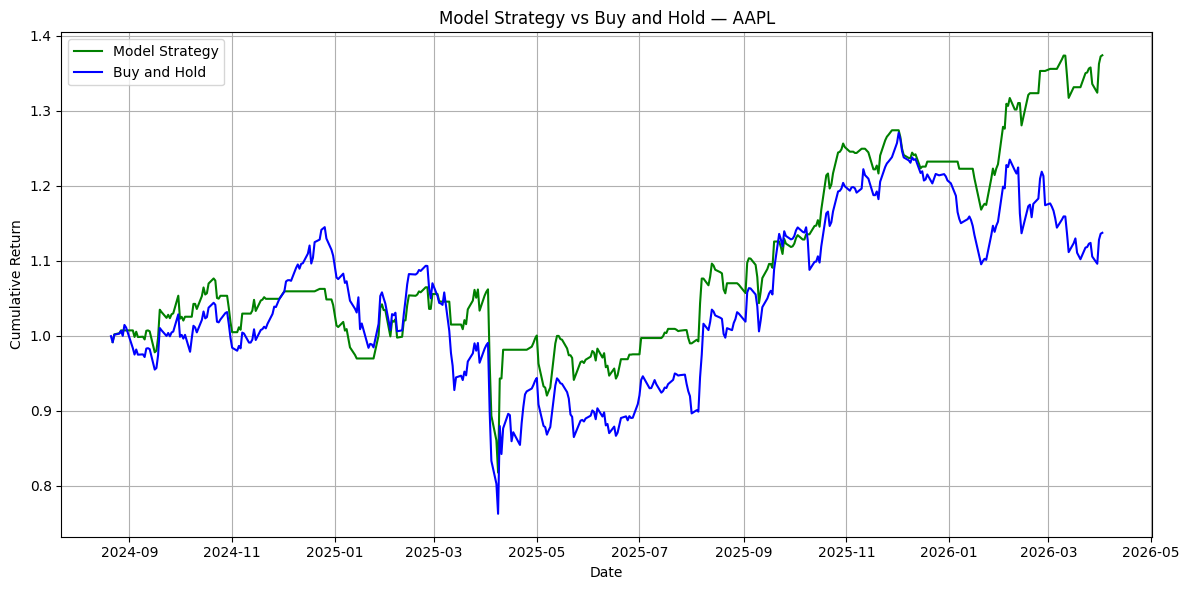

In [68]:
# Visualization: Strategy vs Buy and Hold
# Green line = model strategy cumulative returns
# Blue line = buy and hold cumulative returns
# A green line above blue means the model outperformed simply holding the stock

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test_df.index, test_df["Cumulative_Strategy"], label="Model Strategy", color="green")
plt.plot(test_df.index, test_df["Cumulative_Market"], label="Buy and Hold", color="blue")
plt.title("Model Strategy vs Buy and Hold — AAPL")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()